In [1]:
!pip install requests
!pip install scikit-learn
!pip install duckdb

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Lev\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Lev\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Lev\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Select 500 matches

In [2]:
import duckdb
import pandas as pd

DUCKLAKE_URL = "ducklake:https://s3-cache.deadlock-api.com/db-snapshot/public/db_snapshot.ducklake"


with duckdb.connect() as con:
    con.execute("""
        INSTALL ducklake; LOAD ducklake;
        INSTALL httpfs; LOAD httpfs;
        CREATE OR REPLACE SECRET deadlock_s3 (
            TYPE S3, KEY_ID '', SECRET '',
            ENDPOINT 's3-cache.deadlock-api.com', URL_STYLE 'path', USE_SSL true
        );
    """)
    con.execute(f"ATTACH '{DUCKLAKE_URL}' AS db (READ_ONLY)")
    con.execute("USE db.main")

    # Tables are now queryable directly:
    con.sql("SHOW TABLES").show()
    dataset = con.sql( "SELECT match_id, winning_team, hero_id, team, match_mode, average_badge_team0 " +
        "FROM read_parquet('s3://db-snapshot/public/match_player/match_player_85.parquet')" +
        "WHERE average_badge_team0 > 90 and average_badge_team1 > 90 "+
        "AND match_outcome = 'TeamWin' LIMIT 24000" ).df()
    heroes = con.sql("SELECT * FROM heroes").df()
    heroes.index = heroes["id"]

┌─────────────────────────────┐
│            name             │
│           varchar           │
├─────────────────────────────┤
│ accounts_to_update          │
│ active_matches              │
│ demo_player                 │
│ do_not_use_this_match_info  │
│ hero_leaderboard            │
│ hero_mmr_history            │
│ heroes                      │
│ items                       │
│ leaderboard                 │
│ match_player                │
│ match_salts                 │
│ mmr_history                 │
│ player_card                 │
│ player_match_by_match       │
│ player_match_counts30d_dict │
│ player_match_history        │
└─────────────────────────────┘
            16 rows          



In [3]:
display(dataset)
display(heroes[:10])

num_heroes = len(heroes)

,match_id,winning_team,hero_id,team,match_mode,average_badge_team0
0,85005488,Team1,80,Team1,Unranked,93
1,85005488,Team1,31,Team1,Unranked,93
2,85005488,Team1,17,Team0,Unranked,93
3,85005488,Team1,7,Team1,Unranked,93
4,85005488,Team1,65,Team0,Unranked,93
...,...,...,...,...,...,...
23995,85050864,Team0,50,Team1,Unranked,103
23996,85050864,Team0,52,Team0,Unranked,103
23997,85050864,Team0,1,Team1,Unranked,103
23998,85050864,Team0,64,Team0,Unranked,103


,id,name
id,,
1,1,Infernus
2,2,Seven
3,3,Vindicta
4,4,Lady Geist
6,6,Abrams
7,7,Wraith
8,8,McGinnis
10,10,Paradox
11,11,Dynamo


In [4]:
import numpy as np

def data_preprocessing(dataset : pd.DataFrame, heroes : pd.DataFrame):
    hero_ids = heroes["id"].to_numpy() 

    
    curr_match_id = "0"
    row = [0 for i in range(num_heroes + 2)]
    new_data_np = np.array([row])
           
    for i in range(len(dataset)):
        match_id = dataset.at[i, "match_id"]
        winning_team = dataset.at[i, "winning_team"]
        hero_id = dataset.at[i, "hero_id"]
        team = dataset.at[i, "team"]
        
        if curr_match_id != match_id:
            new_data_np = np.append(new_data_np, [row], axis=0)
                
            row = [0 for i in range(num_heroes + 2)]
            curr_match_id = match_id
            row[0] = curr_match_id
            row[1] = winning_team
            
        hero_row_id = (hero_ids == hero_id).nonzero()[0][0] + 2

        if team == "Team0":
            row[hero_row_id] = 1
        else:
            row[hero_row_id] = -1
    new_data_np = np.append(new_data_np, [row], axis=0)
    new_data_np = np.delete(new_data_np, [0,1], axis=0)

    columns = np.append(["match_id", "winning_team"], hero_ids)

    new_data = pd.DataFrame(new_data_np, columns=columns)
    return new_data
            

In [5]:
dataset_preprocessed = data_preprocessing(dataset, heroes)

target = dataset_preprocessed["winning_team"]
data = dataset_preprocessed.drop(columns=["winning_team", "match_id"]).astype(int)

display(data)

,1,2,3,4,6,7,8,10,11,12,...,65,66,67,69,72,76,77,79,80,81
0,1,0,0,0,0,-1,0,0,0,-1,...,1,0,0,0,1,0,0,0,-1,-1
1,0,1,0,0,-1,-1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,-1,0,0,0,1,-1,-1,0,1,...,0,0,0,-1,1,1,0,0,1,0
3,0,0,0,0,1,0,0,0,1,0,...,-1,0,0,0,0,1,0,-1,-1,0
4,0,-1,-1,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2029,0,0,1,0,0,0,0,-1,1,0,...,-1,-1,0,0,1,0,0,-1,0,0
2030,0,0,0,0,1,0,1,1,0,-1,...,0,0,0,0,0,-1,0,0,1,0
2031,0,1,0,0,0,-1,-1,1,0,0,...,0,0,0,0,0,0,0,-1,0,-1
2032,0,0,0,0,1,0,0,-1,0,0,...,0,-1,1,0,0,1,0,0,1,1


Build model

In [6]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.2, random_state=42)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    LogisticRegression(),
    data_train,
    target_train,
    cv=10,
    scoring="accuracy"
)
cv_results = pd.DataFrame(cv_results)
display(cv_results)

,fit_time,score_time,test_score
0,0.018845,0.002701,0.582822
1,0.013896,0.002516,0.625767
2,0.013848,0.002679,0.644172
3,0.012156,0.002490,0.576687
4,0.014335,0.002352,0.601227
5,0.013688,0.002438,0.564417
6,0.012000,0.002439,0.625767
7,0.011865,0.002360,0.555556
8,0.013909,0.002683,0.586420
9,0.015946,0.002920,0.611111


In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

model_poly = make_pipeline(
    PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
    LogisticRegression()
)

display(model_poly)

cv_results_poly = cross_validate(
    model_poly,
    data_train,
    target_train,
    cv=10
)
cv_results_poly = pd.DataFrame(cv_results_poly)
cv_results_poly

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",True
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` r

,fit_time,score_time,test_score
0,0.078289,0.003766,0.558282
1,0.055740,0.006501,0.515337
2,0.065318,0.003528,0.521472
3,0.060076,0.003512,0.576687
4,0.059374,0.003458,0.564417
5,0.054266,0.003593,0.509202
6,0.056257,0.003768,0.546012
7,0.053545,0.003597,0.530864
8,0.054975,0.003473,0.543210
9,0.059656,0.003418,0.518519


<Axes: ylabel='test_score'>

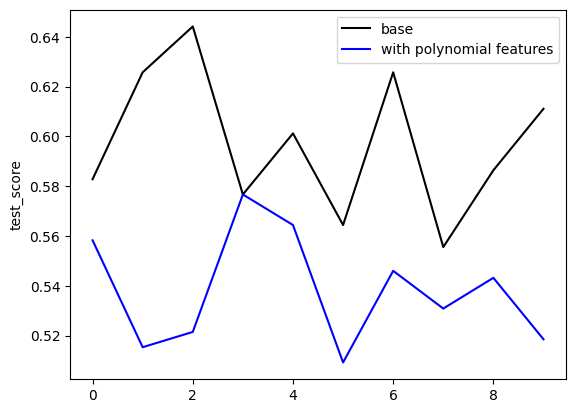

In [9]:
import seaborn as sns

x = np.arange(len(cv_results))
sns.lineplot(y=cv_results["test_score"], x=x, color='black', label="base")
sns.lineplot(y=cv_results_poly["test_score"], x=x, color='blue', label="with polynomial features")

In [10]:
model_poly.get_params()

{'memory': None,
 'steps': [('polynomialfeatures',
   PolynomialFeatures(include_bias=False, interaction_only=True)),
  ('logisticregression', LogisticRegression())],
 'transform_input': None,
 'verbose': False,
 'polynomialfeatures': PolynomialFeatures(include_bias=False, interaction_only=True),
 'logisticregression': LogisticRegression(),
 'polynomialfeatures__degree': 2,
 'polynomialfeatures__include_bias': False,
 'polynomialfeatures__interaction_only': True,
 'polynomialfeatures__order': 'C',
 'logisticregression__C': 1.0,
 'logisticregression__class_weight': None,
 'logisticregression__dual': False,
 'logisticregression__fit_intercept': True,
 'logisticregression__intercept_scaling': 1,
 'logisticregression__l1_ratio': 0.0,
 'logisticregression__max_iter': 100,
 'logisticregression__n_jobs': None,
 'logisticregression__penalty': 'deprecated',
 'logisticregression__random_state': None,
 'logisticregression__solver': 'lbfgs',
 'logisticregression__tol': 0.0001,
 'logisticregression

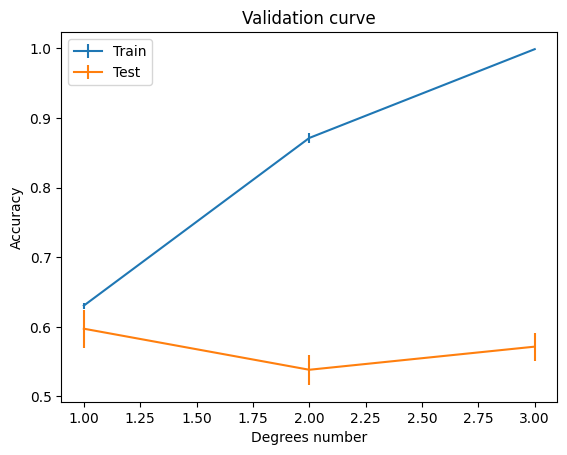

In [11]:
from sklearn.model_selection import ValidationCurveDisplay

degree_range = np.arange(1, 4)

val_curve_disp = ValidationCurveDisplay.from_estimator(
    model_poly,
    data_train,
    target_train,
    param_name='polynomialfeatures__degree',
    param_range=degree_range,
    cv=10,
    std_display_style="errorbar"
)

_ = val_curve_disp.ax_.set(
    xlabel="Degrees number",
    ylabel="Accuracy",
    title="Validation curve"
)
    

Overfitting.

Let's try more samples

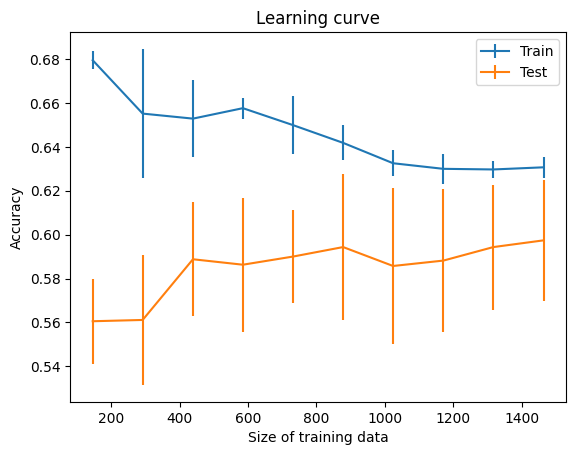

In [15]:
from sklearn.model_selection import LearningCurveDisplay

sizes = np.linspace(0.1, 1, num=10)

learning_curve_disp = LearningCurveDisplay.from_estimator(
    LogisticRegression(),
    data_train,
    target_train,
    cv=10,
    train_sizes=sizes,
    std_display_style="errorbar"
)

_ = learning_curve_disp.ax_.set(
    xlabel="Size of training data",
    ylabel="Accuracy",
    title="Learning curve"
)

It seems adding more data improves accuracy of the model.

In [21]:
DUCKLAKE_URL = "ducklake:https://s3-cache.deadlock-api.com/db-snapshot/public/db_snapshot.ducklake"


with duckdb.connect() as con:
    con.execute("""
        INSTALL ducklake; LOAD ducklake;
        INSTALL httpfs; LOAD httpfs;
        CREATE OR REPLACE SECRET deadlock_s3 (
            TYPE S3, KEY_ID '', SECRET '',
            ENDPOINT 's3-cache.deadlock-api.com', URL_STYLE 'path', USE_SSL true
        );
    """)
    con.execute(f"ATTACH '{DUCKLAKE_URL}' AS db (READ_ONLY)")
    con.execute("USE db.main")

    # Tables are now queryable directly:
    con.sql("SHOW TABLES").show()
    dataset = con.sql( "SELECT match_id, winning_team, hero_id, team, match_mode, average_badge_team0 " +
        "FROM read_parquet(['s3://db-snapshot/public/match_player/match_player_84.parquet']) " +
        "WHERE average_badge_team0 > 90 and average_badge_team1 > 90 "+
        "AND match_outcome = 'TeamWin' LIMIT 100000" ).df()
    heroes = con.sql("SELECT * FROM heroes").df()
    heroes.index = heroes["id"]

┌─────────────────────────────┐
│            name             │
│           varchar           │
├─────────────────────────────┤
│ accounts_to_update          │
│ active_matches              │
│ demo_player                 │
│ do_not_use_this_match_info  │
│ hero_leaderboard            │
│ hero_mmr_history            │
│ heroes                      │
│ items                       │
│ leaderboard                 │
│ match_player                │
│ match_salts                 │
│ mmr_history                 │
│ player_card                 │
│ player_match_by_match       │
│ player_match_counts30d_dict │
│ player_match_history        │
└─────────────────────────────┘
            16 rows          



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [25]:
dataset_preprocessed = data_preprocessing(dataset, heroes)
display(dataset_preprocessed)
data = dataset_preprocessed.drop(columns=["match_id", "winning_team"]).astype(int)
target = dataset_preprocessed["winning_team"]

,match_id,winning_team,1,2,3,4,6,7,8,10,...,65,66,67,69,72,76,77,79,80,81
0,84058735,Team0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,1,0,0,0,-1
1,84058756,Team0,0,-1,0,0,0,0,0,0,...,1,1,0,1,0,-1,0,0,-1,0
2,84058759,Team0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,-1,1,1,0,-1
3,84058783,Team0,-1,1,0,1,0,0,0,0,...,-1,0,0,0,0,0,0,0,0,-1
4,84058785,Team0,0,0,1,0,0,0,0,0,...,-1,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8460,84449213,Team1,0,0,0,0,0,0,0,0,...,0,1,0,1,0,-1,0,1,1,0
8461,84449247,Team1,0,0,0,0,-1,1,0,0,...,0,0,1,0,1,0,0,0,-1,0
8462,84449266,Team0,-1,0,1,0,1,0,-1,0,...,-1,0,0,1,0,0,0,0,0,-1
8463,84449279,Team1,0,-1,0,0,-1,-1,0,0,...,0,-1,1,0,0,-1,0,-1,0,0


In [26]:
data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.2, random_state=42)

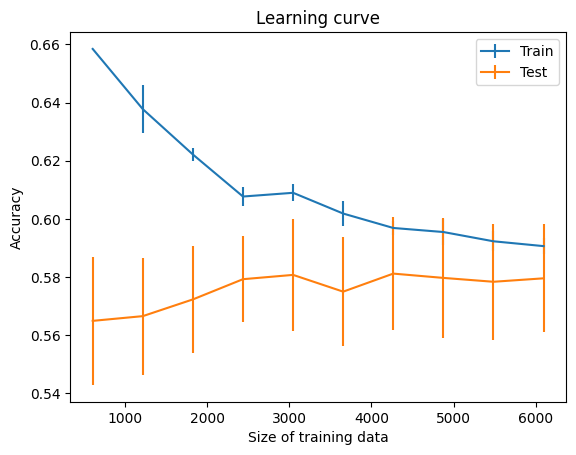

In [27]:
sizes = np.linspace(0.1, 1, num=10)

learning_curve_disp = LearningCurveDisplay.from_estimator(
    LogisticRegression(),
    data_train,
    target_train,
    cv=10,
    train_sizes=sizes,
    std_display_style="errorbar"
)

_ = learning_curve_disp.ax_.set(
    xlabel="Size of training data",
    ylabel="Accuracy",
    title="Learning curve more data"
)

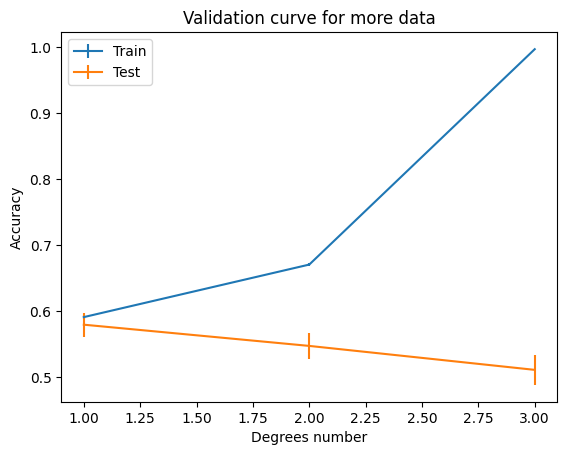

In [35]:
degree_range = np.arange(1, 4)

val_curve_disp = ValidationCurveDisplay.from_estimator(
    model_poly,
    data_train,
    target_train,
    param_name='polynomialfeatures__degree',
    param_range=degree_range,
    cv=10,
    std_display_style="errorbar"
)

_ = val_curve_disp.ax_.set(
    xlabel="Degrees number",
    ylabel="Accuracy",
    title="Validation curve for more data"
)

The most simple model is the best model.

However it can't take into account the connections between heroes.

Now I understand, that complexer models can't see the relativity of combined params.
For example:

    We have McGinnes on Team0 and Abrams on Team1. 
    McGinnes x Abrams = 1 * -1 = -1

    
    that's the same as Abrams on Team0 and McGinnes on Team1
    Abrams x McGinnes = -1 * 1 = -1

The model doesn't understand how to differantiate between these states.

We have 2 ways of solving this problem:

1. Use Decision trees
2. Double the features. Instead of:

        McGinnis | Abrams
        1          -1

        make:
        
        McGinnis Team0 | McGinnis Team1 | Abrams Team0 | Abrams Team1
        1                0                0              1


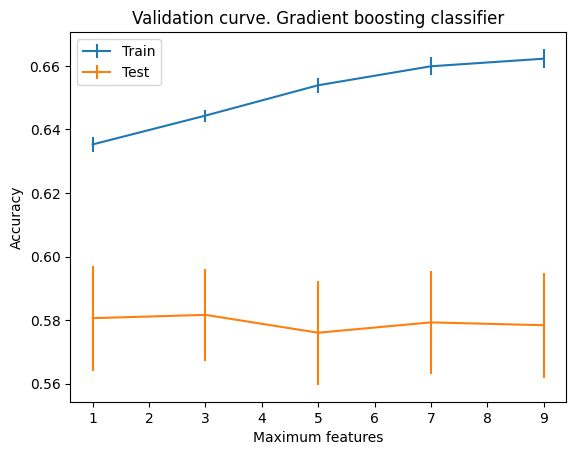

In [56]:
from sklearn.ensemble import GradientBoostingClassifier

gbc =  GradientBoostingClassifier( n_estimators=300,
                                 learning_rate=0.05,
                                 random_state=100,
                                 max_features=5 )

features_range = np.arange(1, 10, 2)

val_curve_disp = ValidationCurveDisplay.from_estimator(
    gbc,
    data_train,
    target_train,
    param_name='max_features',
    param_range=features_range,
    cv=10,
    std_display_style="errorbar"
)

_ = val_curve_disp.ax_.set(
    xlabel="Maximum features",
    ylabel="Accuracy",
    title="Validation curve. Gradient boosting classifier"
)


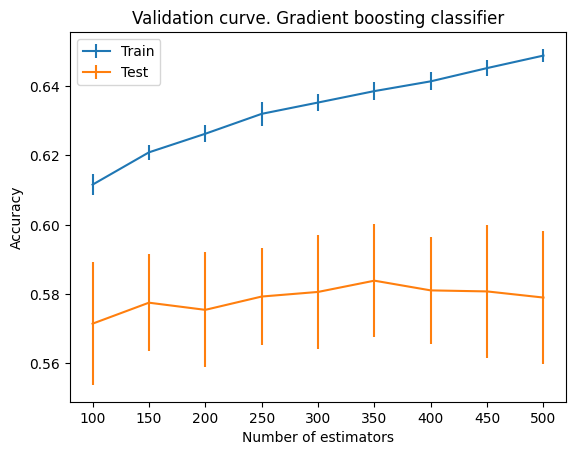

In [57]:
max_features = 1

gbc = GradientBoostingClassifier( n_estimators=300,
                                 learning_rate=0.05,
                                 random_state=100,
                                 max_features=max_features )

n_estimators_range = np.arange(100, 550, 50)

val_curve_disp = ValidationCurveDisplay.from_estimator(
    gbc,
    data_train,
    target_train,
    param_name='n_estimators',
    param_range=n_estimators_range,
    cv=10,
    std_display_style="errorbar"
)

_ = val_curve_disp.ax_.set(
    xlabel="Number of estimators",
    ylabel="Accuracy",
    title="Validation curve. Gradient boosting classifier"
)